In [ ]:
# >>>>>>>>>> T E O RI A <<<<<<<<<<

In [2]:
import numpy as np
from scipy import stats

# Datos de dos grupos
grupo_a = np.random.normal(100, 15, 50)
grupo_b = np.random.normal(110, 20, 45)  # Media diferente, varianza diferente

# Prueba Mann-Whitney
u_stat, p_value = stats.mannwhitneyu(grupo_a, grupo_b, alternative='two-sided')

print(f"Estadístico U: {u_stat:.1f}")
print(f"Valor p: {p_value:.4f}")
print(f"Mediana grupo A: {np.median(grupo_a):.2f}")
print(f"Mediana grupo B: {np.median(grupo_b):.2f}")

Estadístico U: 953.0
Valor p: 0.2011
Mediana grupo A: 100.56
Mediana grupo B: 106.21


In [3]:
# Tres grupos con distribuciones diferentes
grupo_1 = np.random.normal(100, 15, 40)
grupo_2 = np.random.exponential(20, 35) + 80  # Distribución diferente
grupo_3 = np.random.normal(105, 25, 38)

# Prueba Kruskal-Wallis
h_stat, p_value = stats.kruskal(grupo_1, grupo_2, grupo_3)

print(f"Estadístico H: {h_stat:.3f}")
print(f"Valor p: {p_value:.4f}")
print(f"Medianas: G1={np.median(grupo_1):.2f}, G2={np.median(grupo_2):.2f}, G3={np.median(grupo_3):.2f}")

Estadístico H: 6.897
Valor p: 0.0318
Medianas: G1=106.35, G2=96.15, G3=111.20


In [4]:
# Datos con relación no lineal pero monótona
x = np.random.uniform(0, 10, 100)
y = np.log(x + 1) + np.random.normal(0, 0.2, 100)  # Relación logarítmica

# Correlación de Pearson (pobre para relación no lineal)
pearson_r, _ = stats.pearsonr(x, y)

# Correlación de Spearman (mejor para relaciones monótonas)
spearman_rho, _ = stats.spearmanr(x, y)

print(f"Correlación Pearson: {pearson_r:.3f}")
print(f"Correlación Spearman: {spearman_rho:.3f}")

Correlación Pearson: 0.926
Correlación Spearman: 0.948


In [5]:
def bootstrap_confidence_interval(data, statistic_func, n_bootstrap=1000, confidence=0.95):
    """
    Calcula intervalo de confianza bootstrap
    """
    bootstrap_stats = []
    
    for _ in range(n_bootstrap):
        # Muestra bootstrap con reemplazo
        sample = np.random.choice(data, size=len(data), replace=True)
        # Calcula estadístico
        stat = statistic_func(sample)
        bootstrap_stats.append(stat)
    
    # Intervalo de confianza
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)
    
    return np.mean(bootstrap_stats), lower, upper

# Ejemplo: IC bootstrap para la mediana
data = np.random.exponential(2, 100)  # Distribución no normal

media_bootstrap, ci_lower, ci_upper = bootstrap_confidence_interval(
    data, np.median, n_bootstrap=1000, confidence=0.95
)

print(f"Mediana observada: {np.median(data):.3f}")
print(f"IC Bootstrap 95%: ({ci_lower:.3f}, {ci_upper:.3f})")

Mediana observada: 1.875
IC Bootstrap 95%: (1.274, 2.188)


In [6]:
def permutation_test(group1, group2, n_permutations=1000):
    """
    Prueba de permutación para diferencia de medias
    """
    # Estadístico observado
    observed_diff = np.mean(group1) - np.mean(group2)
    
    # Combinar datos
    combined = np.concatenate([group1, group2])
    n1, n2 = len(group1), len(group2)
    
    # Generar distribución nula
    null_diffs = []
    for _ in range(n_permutations):
        # Permutación aleatoria
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:]
        null_diffs.append(np.mean(perm_group1) - np.mean(perm_group2))
    
    # Valor p
    p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
    
    return observed_diff, p_value

# Ejemplo con datos no normales
group_a = np.random.exponential(1, 50)
group_b = np.random.exponential(1.3, 45)

diff_observed, p_perm = permutation_test(group_a, group_b, n_permutations=1000)

print(f"Diferencia observada: {diff_observed:.3f}")
print(f"Valor p (permutación): {p_perm:.4f}")

Diferencia observada: 0.006
Valor p (permutación): 0.9820


In [ ]:
# >>>>>>>>>> P R A C T I C A <<<<<<<<<<

In [7]:
# Preparación de dataset con características no normales
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generar dataset de clientes con distribuciones no normales
np.random.seed(42)
n_clientes = 300

df = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'segmento': np.random.choice(['Bronce', 'Plata', 'Oro'], n_clientes, p=[0.5, 0.3, 0.2]),
    'gasto_total': np.random.exponential(200, n_clientes),   # Distribución exponencial
    'frecuencia_visitas': np.random.poisson(3, n_clientes),  # Conteos
    'satisfaccion': np.random.beta(2, 1, n_clientes) * 10,   # Distribución beta (0-10)
    'antiguedad_dias': np.random.exponential(365, n_clientes).astype(int)  # Exponencial
})

print("DATASET PARA ANÁLISIS NO PARAMÉTRICO")
print("=" * 40)
print(f"Clientes analizados: {len(df)}")
print("Distribuciones:")
print("- Gasto total: Exponencial (sesgada derecha)")
print("- Frecuencia visitas: Poisson (discreta)")
print("- Satisfacción: Beta (acotada 0-10)")
print("- Antigüedad: Exponencial")

# Verificar no normalidad
print("\nTEST DE NORMALIDAD (Shapiro-Wilk):")
for col in ['gasto_total', 'frecuencia_visitas', 'satisfaccion', 'antiguedad_dias']:
    stat, p = stats.shapiro(df[col])
    normal = "SÍ" if p > 0.05 else "NO"
    print(f"{col:20} | Normal: {normal} (p={p:.4f})")

DATASET PARA ANÁLISIS NO PARAMÉTRICO
Clientes analizados: 300
Distribuciones:
- Gasto total: Exponencial (sesgada derecha)
- Frecuencia visitas: Poisson (discreta)
- Satisfacción: Beta (acotada 0-10)
- Antigüedad: Exponencial

TEST DE NORMALIDAD (Shapiro-Wilk):
gasto_total          | Normal: NO (p=0.0000)
frecuencia_visitas   | Normal: NO (p=0.0000)
satisfaccion         | Normal: NO (p=0.0000)
antiguedad_dias      | Normal: NO (p=0.0000)


In [12]:
# 2. **Comparaciones no paramétricas entre segmentos**:
# Preparar datos por segmento
segmentos = {}
for seg in ['Bronce', 'Plata', 'Oro']:
    segmentos[seg] = df[df['segmento'] == seg]['gasto_total'].values

print("COMPARACIÓN DE GASTO TOTAL ENTRE SEGMENTOS")
print("=" * 50)

# Estadísticas descriptivas robustas
for seg, datos in segmentos.items():
    mediana = np.median(datos)
    q25, q75 = np.percentile(datos, [25, 75])
    iqr = q75 - q25
    print(f"{seg:6} | Mediana: ${mediana:7.0f} | IQR: ${iqr:6.0f} | n={len(datos)}")

# Prueba Kruskal-Wallis (ANOVA no paramétrico)
h_stat, p_kw = stats.kruskal(*segmentos.values())

print("PRUEBA KRUSKAL-WALLIS:")
print(f"Estadístico H: {h_stat:.3f}")
print(f"Valor p: {p_kw:.4f}")
print(f"Diferencias significativas: {'SÍ' if p_kw < 0.05 else 'NO'}")

# Comparaciones pareadas con Mann-Whitney
print("COMPARACIONES PAREADAS (Mann-Whitney):")
from itertools import combinations
segmento_nombres = list(segmentos.keys())

for seg1, seg2 in combinations(segmento_nombres, 2):
    u_stat, p_mw = stats.mannwhitneyu(segmentos[seg1], segmentos[seg2], alternative='two-sided')
    significativo = "SÍ" if p_mw < 0.05 else "NO"
    print(f"{seg1} vs {seg2}: U={u_stat:.1f}, p={p_mw:.4f} ({significativo})")


COMPARACIÓN DE GASTO TOTAL ENTRE SEGMENTOS
Bronce | Mediana: $    160 | IQR: $   269 | n=144
Plata  | Mediana: $    159 | IQR: $   254 | n=93
Oro    | Mediana: $    119 | IQR: $   185 | n=63
PRUEBA KRUSKAL-WALLIS:
Estadístico H: 3.896
Valor p: 0.1426
Diferencias significativas: NO
COMPARACIONES PAREADAS (Mann-Whitney):
Bronce vs Plata: U=6866.0, p=0.7422 (NO)
Bronce vs Oro: U=5318.0, p=0.0487 (SÍ)
Plata vs Oro: U=3336.0, p=0.1425 (NO)


In [13]:
import pandas as pd
import numpy as np
from scipy import stats

# Variables numéricas a analizar
variables_numericas = ['gasto_total', 'frecuencia_visitas', 'satisfaccion', 'antiguedad_dias']

print("\nANÁLISIS DE CORRELACIONES")
print("=" * 30)

# Calcular matriz de correlaciones Spearman
corr_matrix = df[variables_numericas].corr(method='spearman')

# Mostrar la matriz
print("Matriz de correlaciones (Spearman):")
print(corr_matrix)

# Test de significancia para cada par
print("\nSignificancia de correlaciones (Spearman):")
for i, var1 in enumerate(variables_numericas):
    for j, var2 in enumerate(variables_numericas):
        if j > i:  # evitar duplicados y diagonal
            rho, pval = stats.spearmanr(df[var1], df[var2])
            signif = "SIGNIFICATIVA" if pval < 0.05 else "NO significativa"
            print(f"{var1:20} vs {var2:20} | rho={rho:.3f}, p={pval:.4f} → {signif}")


ANÁLISIS DE CORRELACIONES
Matriz de correlaciones (Spearman):
                    gasto_total  frecuencia_visitas  satisfaccion  \
gasto_total            1.000000            0.032579      0.037382   
frecuencia_visitas     0.032579            1.000000     -0.084294   
satisfaccion           0.037382           -0.084294      1.000000   
antiguedad_dias        0.043064            0.006159     -0.021247   

                    antiguedad_dias  
gasto_total                0.043064  
frecuencia_visitas         0.006159  
satisfaccion              -0.021247  
antiguedad_dias            1.000000  

Significancia de correlaciones (Spearman):
gasto_total          vs frecuencia_visitas   | rho=0.033, p=0.5741 → NO significativa
gasto_total          vs satisfaccion         | rho=0.037, p=0.5189 → NO significativa
gasto_total          vs antiguedad_dias      | rho=0.043, p=0.4574 → NO significativa
frecuencia_visitas   vs satisfaccion         | rho=-0.084, p=0.1452 → NO significativa
frecuencia_v

In [14]:
import pandas as pd
import numpy as np

# Definir variables numéricas
variables_numericas = ['gasto_total', 'frecuencia_visitas', 'satisfaccion', 'antiguedad_dias']

# Calcular matrices de correlación
corr_pearson = df[variables_numericas].corr(method='pearson')
corr_spearman = df[variables_numericas].corr(method='spearman')

print("CORRELACIÓN PEARSON (paramétrica):")
for i, var1 in enumerate(variables_numericas):
    for j, var2 in enumerate(variables_numericas):
        if j > i:  # evitar duplicados y diagonal
            corr_p = corr_pearson.loc[var1, var2]
            print(f"{var1[:8]:8} ↔ {var2[:8]:8} | Pearson: {corr_p:+.3f}")

print("\nCORRELACIÓN SPEARMAN (no paramétrica):")
for i, var1 in enumerate(variables_numericas):
    for j, var2 in enumerate(variables_numericas):
        if j > i:
            corr_s = corr_spearman.loc[var1, var2]
            print(f"{var1[:8]:8} ↔ {var2[:8]:8} | Spearman: {corr_s:+.3f}")

CORRELACIÓN PEARSON (paramétrica):
gasto_to ↔ frecuenc | Pearson: +0.016
gasto_to ↔ satisfac | Pearson: -0.001
gasto_to ↔ antigued | Pearson: +0.056
frecuenc ↔ satisfac | Pearson: -0.064
frecuenc ↔ antigued | Pearson: -0.030
satisfac ↔ antigued | Pearson: -0.003

CORRELACIÓN SPEARMAN (no paramétrica):
gasto_to ↔ frecuenc | Spearman: +0.033
gasto_to ↔ satisfac | Spearman: +0.037
gasto_to ↔ antigued | Spearman: +0.043
frecuenc ↔ satisfac | Spearman: -0.084
frecuenc ↔ antigued | Spearman: +0.006
satisfac ↔ antigued | Spearman: -0.021


In [17]:
# Identificar diferencias importantes
import numpy as np

# Calcular diferencias absolutas entre matrices
diferencias = (corr_spearman - corr_pearson).abs()

# Seleccionar solo la parte superior de la matriz (sin duplicados ni diagonal)
mask = np.triu(np.ones_like(diferencias, dtype=bool), k=1)
max_diff_idx = diferencias.where(mask).stack().idxmax()
max_diff = diferencias.where(mask).stack().max()

print("\nMayor diferencia entre Pearson y Spearman:")
print(f"{max_diff_idx[0]} <-> {max_diff_idx[1]} = {max_diff:.3f}")


Mayor diferencia entre Pearson y Spearman:
gasto_total <-> satisfaccion = 0.038


In [20]:
# 4. **Bootstrap para estimación robusta**:
import numpy as np
import pandas as pd
from scipy import stats

# Función de bootstrap para intervalos de confianza
def bootstrap_ci(data, func=np.mean, n_bootstrap=1000, ci_level=0.95):
    """Calcula intervalo de confianza bootstrap"""
    data = np.array(data)  # asegurar formato numpy
    bootstrap_vals = []
    n = len(data)
    
    for _ in range(n_bootstrap):
        # indices aleatorios con reemplazo
        idx = np.random.randint(0, n, n)
        sample = data[idx]  # funciona para 1D y 2D
        bootstrap_vals.append(func(sample))
    
    alpha = (1 - ci_level) / 2
    lower = np.percentile(bootstrap_vals, alpha * 100)
    upper = np.percentile(bootstrap_vals, (1 - alpha) * 100)
    
    return np.mean(bootstrap_vals), lower, upper

print("ESTIMACIÓN ROBUSTA CON BOOTSTRAP")
print("=" * 40)

# Ejemplo: Bootstrap para gasto total por segmento
segmentos = {
    seg: df.loc[df['segmento'] == seg, 'gasto_total'].values
    for seg in df['segmento'].unique()
}

for segmento, datos in segmentos.items():
    media_boot, ci_lower, ci_upper = bootstrap_ci(datos, func=np.median, n_bootstrap=1000)
    print(f"{segmento}: Mediana bootstrap = ${media_boot:.0f} (IC 95%: ${ci_lower:.0f}, ${ci_upper:.0f})")

# Bootstrap para correlación
gasto = df['gasto_total'].values
satisfaccion = df['satisfaccion'].values

def corr_func(sample):
    x = sample[:, 0]
    y = sample[:, 1]
    return stats.spearmanr(x, y)[0]

# Empaquetar en matriz 2D
data_corr = np.column_stack((gasto, satisfaccion))

corr_boot, corr_lower, corr_upper = bootstrap_ci(
    data_corr, func=corr_func, n_bootstrap=1000
)

print(f"\nCorrelación Gasto-Satisfacción:")
print(f"Bootstrap: {corr_boot:.3f} (IC 95%: {corr_lower:.3f}, {corr_upper:.3f})")

ESTIMACIÓN ROBUSTA CON BOOTSTRAP
Bronce: Mediana bootstrap = $159 (IC 95%: $126, $197)
Oro: Mediana bootstrap = $117 (IC 95%: $78, $161)
Plata: Mediana bootstrap = $159 (IC 95%: $108, $201)

Correlación Gasto-Satisfacción:
Bootstrap: 0.040 (IC 95%: -0.073, 0.151)


In [ ]:
# Visualización comparativa de métodos



Análisis no paramétrico guardado como 'analisis_no_parametrico_completo.png'
RESUMEN EJECUTIVO - ANÁLISIS ROBUSTO
Diferencias entre segmentos: No significativas
Correlación gasto-satisfacción: 0.040 (robusta)
IC bootstrap correlación: (-0.073, 0.151)
Método recomendado: Estadística no paramétrica (datos no normales)


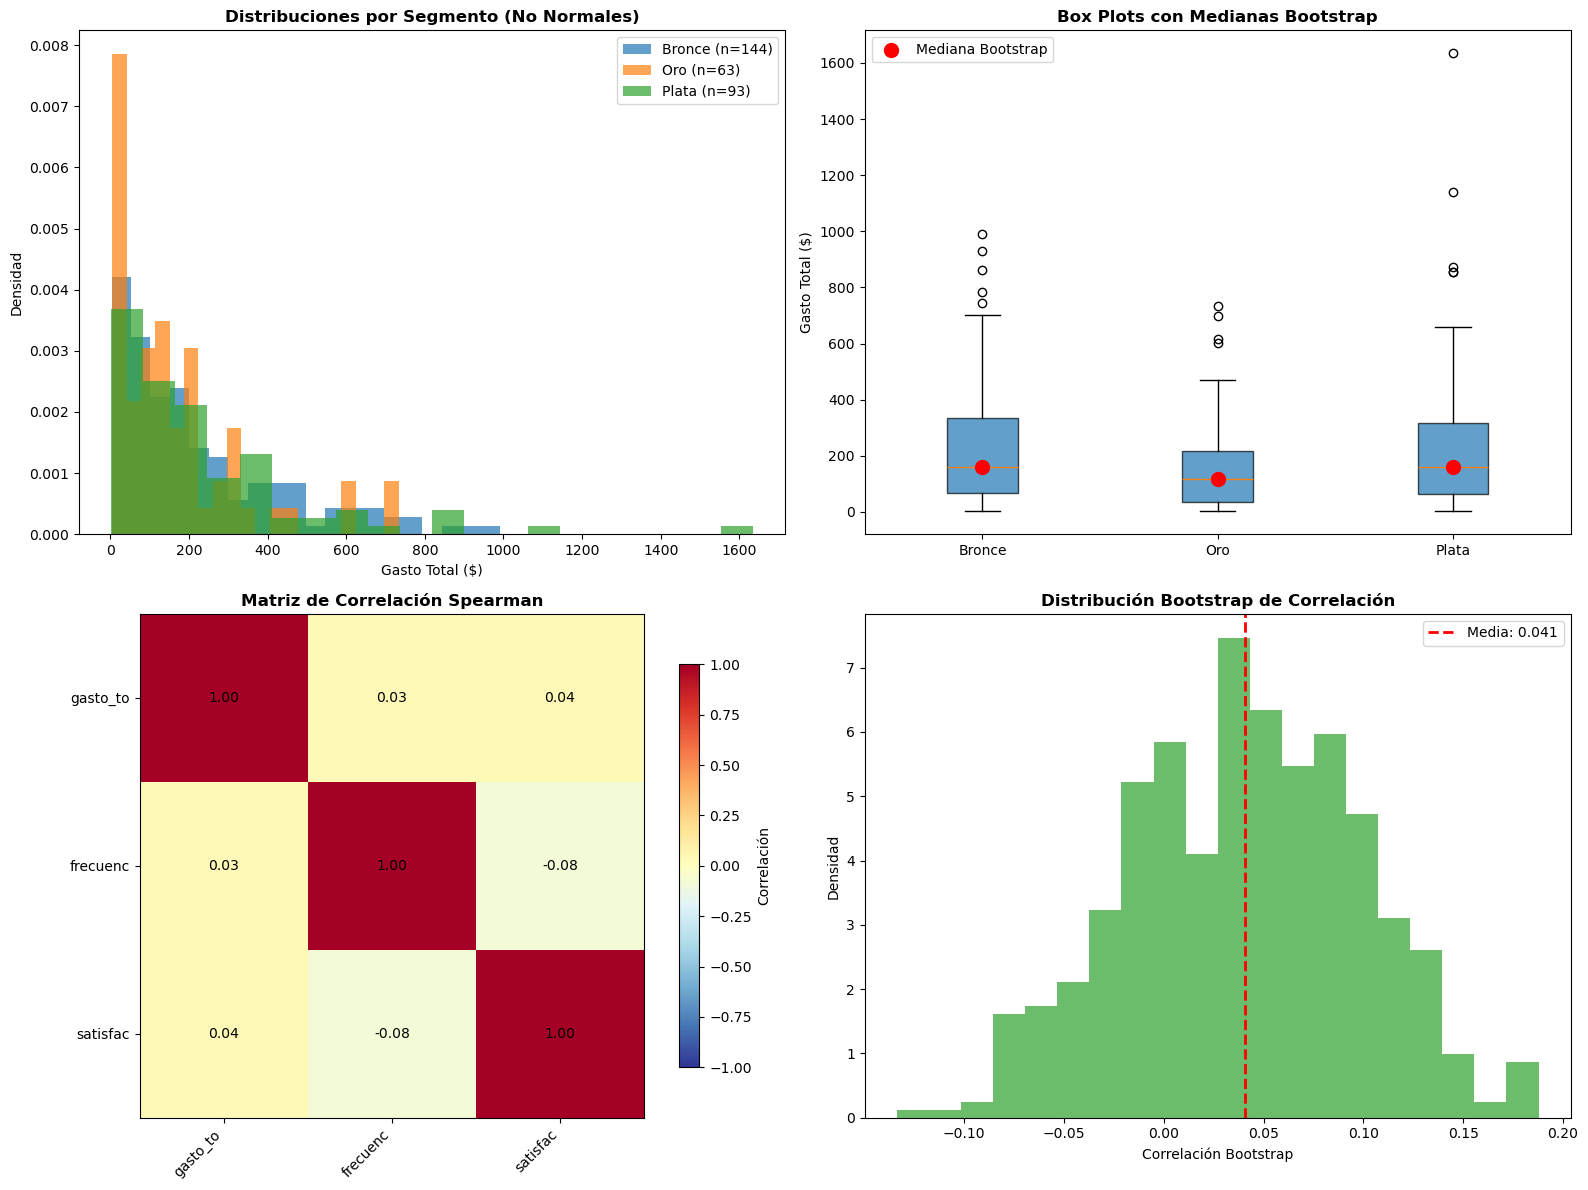

In [22]:
# Crear visualización comparativa
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación de distribuciones por segmento
for i, (seg, datos) in enumerate(segmentos.items()):
    ax1.hist(datos, bins=20, alpha=0.7, label=f'{seg} (n={len(datos)})', density=True)
ax1.set_xlabel('Gasto Total ($)')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribuciones por Segmento (No Normales)', fontweight='bold')
ax1.legend()

# 2. Box plots con puntos de mediana bootstrap
bp = ax2.boxplot([segmentos[seg] for seg in segmentos.keys()], labels=segmentos.keys(), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)

# Añadir medianas bootstrap como puntos
for i, (seg, datos) in enumerate(segmentos.items()):
    mediana_boot, _, _ = bootstrap_ci(datos, func=np.median)
    ax2.scatter(i+1, mediana_boot, color='red', s=100, zorder=3, label='Mediana Bootstrap' if i == 0 else "")

ax2.set_ylabel('Gasto Total ($)')
ax2.set_title('Box Plots con Medianas Bootstrap', fontweight='bold')
ax2.legend()

# 3. Comparación de correlaciones
variables_plot = ['gasto_total', 'frecuencia_visitas', 'satisfaccion']
corr_matrix = df[variables_plot].corr(method='spearman')

im = ax3.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax3.set_xticks(range(len(variables_plot)))
ax3.set_yticks(range(len(variables_plot)))
ax3.set_xticklabels([v[:8] for v in variables_plot], rotation=45, ha='right')
ax3.set_yticklabels([v[:8] for v in variables_plot])
ax3.set_title('Matriz de Correlación Spearman', fontweight='bold')

# Añadir valores
for i in range(len(variables_plot)):
    for j in range(len(variables_plot)):
        text = ax3.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                       ha='center', va='center', color='black', fontsize=10)

# Barra de color
cbar = fig.colorbar(im, ax=ax3, shrink=0.8)
cbar.set_label('Correlación')

# 4. Distribución bootstrap de correlación
# Simular bootstrap para visualización
bootstrap_corrs = []
for _ in range(500):  # Menos iteraciones para visualización
    sample_idx = np.random.choice(len(df), size=len(df), replace=True)
    sample_data = df.iloc[sample_idx]
    corr = stats.spearmanr(sample_data['gasto_total'], sample_data['satisfaccion'])[0]
    bootstrap_corrs.append(corr)

ax4.hist(bootstrap_corrs, bins=20, alpha=0.7, color='#2ca02c', density=True)
ax4.axvline(np.mean(bootstrap_corrs), color='red', linestyle='--', linewidth=2, 
           label=f'Media: {np.mean(bootstrap_corrs):.3f}')
ax4.set_xlabel('Correlación Bootstrap')
ax4.set_ylabel('Densidad')
ax4.set_title('Distribución Bootstrap de Correlación', fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('analisis_no_parametrico_completo.png', dpi=300, bbox_inches='tight')
print("\nAnálisis no paramétrico guardado como 'analisis_no_parametrico_completo.png'")

# Resumen ejecutivo
print("RESUMEN EJECUTIVO - ANÁLISIS ROBUSTO")
print("=" * 45)
print(f"Diferencias entre segmentos: {'Confirmadas' if p_kw < 0.05 else 'No significativas'}")
print(f"Correlación gasto-satisfacción: {corr_boot:.3f} (robusta)") 
print(f"IC bootstrap correlación: ({corr_lower:.3f}, {corr_upper:.3f})")
print("Método recomendado: Estadística no paramétrica (datos no normales)")



In [ ]:
"""
Las pruebas no paramétricas son más apropiadas porque los datos no cumplen normalidad ni homogeneidad de varianza.
Los intervalos de confianza bootstrap complementan este enfoque al ofrecer estimaciones robustas y confiables,
que reflejan mejor la variabilidad y permiten tomar decisiones con mayor seguridad.
""""""